In [713]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import ssl

In [714]:
ssl._create_default_https_context = ssl._create_unverified_context

In [715]:
digits = fetch_openml('mnist_784')
print(f"{digits.data.shape} {digits.target.shape}")

(70000, 784) (70000,)


In [716]:
data = load_digits()

In [717]:
digits = data.data


In [718]:
data.target.astype(int)

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

In [719]:
target = data.target.astype(int)

In [720]:
scaler = StandardScaler()
n_images = len(data.data)
data = data.data/data.data.max()

In [721]:
from sklearn.preprocessing import OneHotEncoder

In [722]:
target.reshape(-1,1).shape

(1797, 1)

In [723]:
enc = OneHotEncoder(sparse_output=False)

target = enc.fit_transform(target.reshape(-1,1))

In [724]:
X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.3, shuffle=False
)

In [725]:

# y_train = np.expand_dims(y_train, axis=0)
# y_test = np.expand_dims(y_test, axis=0)


y_train = y_train.reshape(y_train.shape[1],y_train.shape[0])
y_test = y_test.reshape(y_test.shape[1], y_test.shape[0])


In [726]:
print(f"shape train {X_train.shape} shape test {X_test.shape} {y_train.shape} {y_test.shape}")

shape train (1257, 64) shape test (540, 64) (10, 1257) (10, 540)


In [727]:
def layer_size(X, y):
    return X.shape[0], y.shape[0]
    

In [ ]:
## Inicializamos los pesos

def initialize_parameters(n_h = 1, n_x = 2, n_y = 1):
    
    scale_factor = 0.001
    
    w_1 = np.random.randn(n_h, n_x) * np.sqrt(2 / n_x)
    b1 = np.zeros((n_h, 1)) 
    w_2 = np.random.randn(n_y, n_h) * np.sqrt(1/n_h)
    b2 = np.zeros((n_y, 1))

    # parameters = {"W1": w1,
    #               "b1": b1,
    #               "W2": w2,
    #               "b2": b2}
    
    return w_1, b1, w_2, b2

### Tendremos una entrada de dos neuronas, una capa oculta de 4 y una salidad de 1 neurona

# Definimos nuestra función de activación

In [729]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def softmax(Z):
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)  # evita overflow
    expZ = np.exp(Z_shift)
    return expZ / np.sum(expZ, axis=0, keepdims=True)


### Forward propagation

In [730]:
def forward(X, w_1, b1, w_2, b2):
    # print(f"{X.shape} {w_1.shape} {b1.shape} {w_2.shape} {b2.shape}")
    Z1 = np.dot(w_1, X) + b1 
    A1 = relu(Z1) 
    Z2 = np.dot(w_2, A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

In [731]:
def cost(A2, Y):##
    m = Y.shape[1]
    # logprobs =   np.multiply(np.log(A2),Y)+np.multiply((1-Y),np.log(1-A2)) 
    cost = - np.sum(Y * np.log(A2))/m
    cost = float(np.squeeze(cost))
    return cost

In [732]:
def backward_propagation(w1, w2, b1, b2, A1,A2, X,Y, z1):
    m = X.shape[1]
    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = (np.dot(w2.T, dZ2))#  1 - np.power(A1, 2)
    dZ1[z1 <= 0] = 0
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    grads = {
        "dw1": dW1, "dw2": dW2, "db1": db1, "db2": db2
    }
    return grads


In [733]:
def update_parameters(w1, w2, b1, b2, grads, learning_rate):

    dW1 = grads.get("dw1") 
    dW2 = grads.get("dw2") 
    db1 = grads.get("db1") 
    db2 = grads.get("db2") 

    w1 -= learning_rate*dW1
    w2 -= learning_rate*dW2
    b1 -= learning_rate*db1
    b2 -= learning_rate*db2

    return {"w1":w1, "w2":w2, "b1":b1, "b2":b2}

In [734]:
def predict(parameters, X):
    w1 = parameters.get("w1")
    w2 = parameters.get("w2")
    b1 = parameters.get("b1")
    b2 = parameters.get("b2")
    _,_,_,A2 = forward(X, w1,b1,w2,b2)
    return np.argmax(A2, axis=0) 



In [735]:
def neural_network(X,Y, n_h, learning_rate, num_iterations=500, print_cost=False, debug=False):
    n_x, n_y= layer_size(X, Y)
    print(f"{n_x} --- {n_y}")
    w1,b1,w2,b2 = initialize_parameters(n_h, n_x, n_y)
    for i in range(0,num_iterations):
        Z1, A1, Z2, A2, = forward(X, w1,b1, w2,b2)
        # computed_cost = cost(A2, Y)
        grads = backward_propagation(w1,w2,b1,b2,A1,A2,X,Y, Z1)
        updated_parameters = update_parameters(w1,w2,b1,b2, grads, learning_rate)
        w1 = updated_parameters.get("w1")
        w2 = updated_parameters.get("w2")
        b1 = updated_parameters.get("b1")
        b2 = updated_parameters.get("b2")
        if print_cost and i % 1000 == 0:
            y_pred = predict(updated_parameters, X)
            y_true = np.argmax(Y, axis=0)
            print(f"Accuracy on iteration{i}: {accuracy_score(y_true, y_pred)}")

        if debug and i % 1000 == 0:
                # Debugging prints: rangos y normas de gradientes
                print("DEBUG iter", i, "Z2 min/max:", np.min(Z2), np.max(Z2))
                print("A2 min/max:", np.min(A2), np.max(A2))
                # grad norms
                print("||dW1||, ||dW2||:", np.linalg.norm(grads.get("dw1") ), np.linalg.norm(grads.get("dw2")))
                print("-"*12)
    return updated_parameters
    




In [743]:
parameters = neural_network(X_train.T, y_train, 84 ,1e-2,num_iterations=80000,print_cost=True, debug=True)


64 --- 10
Accuracy on iteration0: 0.06762132060461416
DEBUG iter 0 Z2 min/max: -1.5416342703298518 1.7844357139429026
A2 min/max: 0.016199160775373107 0.34247879672101456
||dW1||, ||dW2||: 0.3789972276234329 0.6369359809566617
------------
Accuracy on iteration1000: 0.10660302307080351
DEBUG iter 1000 Z2 min/max: -0.7042240900612518 1.0224223030329351
A2 min/max: 0.03918042714107809 0.1966726133112486
||dW1||, ||dW2||: 0.030651751413313427 0.040743048064881146
------------
Accuracy on iteration2000: 0.10580747812251393
DEBUG iter 2000 Z2 min/max: -0.583351547978427 1.2167587217933618
A2 min/max: 0.04114773139203097 0.20070428032193302
||dW1||, ||dW2||: 0.026272156225145952 0.03459397118420386
------------
Accuracy on iteration3000: 0.1177406523468576
DEBUG iter 3000 Z2 min/max: -0.500902211910249 1.4290861073045515
A2 min/max: 0.039281250578890946 0.21270610883144314
||dW1||, ||dW2||: 0.02570090097933251 0.0328841532894253
------------
Accuracy on iteration4000: 0.1249005568814638
DEBU

In [737]:
predictions = predict(parameters, X_test.T)


In [738]:
predictions

array([0, 5, 3, 3, 6, 1, 6, 6, 2, 3, 0, 5, 1, 0, 6, 9, 9, 0, 6, 1, 9, 8,
       2, 1, 8, 4, 2, 2, 5, 2, 4, 1, 0, 9, 1, 1, 8, 2, 7, 1, 6, 1, 0, 4,
       8, 9, 8, 2, 0, 7, 4, 4, 5, 2, 1, 5, 8, 2, 9, 7, 4, 4, 9, 2, 8, 2,
       5, 3, 2, 4, 5, 8, 1, 3, 2, 2, 8, 1, 8, 8, 0, 0, 2, 0, 0, 1, 4, 5,
       0, 4, 4, 2, 8, 4, 0, 5, 3, 6, 8, 4, 1, 5, 0, 5, 2, 6, 5, 5, 0, 4,
       1, 2, 6, 2, 0, 1, 6, 0, 8, 4, 1, 3, 3, 1, 9, 8, 6, 2, 4, 0, 5, 0,
       1, 9, 8, 6, 3, 5, 7, 1, 8, 8, 1, 9, 2, 0, 9, 1, 5, 1, 2, 8, 2, 0,
       0, 8, 1, 9, 8, 5, 4, 5, 2, 3, 6, 8, 5, 4, 8, 5, 2, 8, 8, 2, 6, 8,
       3, 8, 8, 5, 1, 5, 8, 9, 2, 8, 5, 4, 4, 8, 9, 9, 6, 8, 4, 4, 5, 3,
       5, 9, 5, 3, 5, 9, 2, 5, 4, 4, 3, 3, 8, 5, 3, 3, 4, 3, 7, 6, 9, 8,
       0, 3, 8, 3, 7, 1, 8, 4, 4, 9, 4, 3, 9, 4, 6, 3, 4, 8, 4, 5, 5, 5,
       0, 4, 2, 8, 6, 3, 4, 9, 4, 5, 3, 6, 5, 8, 4, 5, 8, 4, 8, 6, 6, 4,
       8, 4, 5, 8, 8, 2, 8, 3, 5, 3, 3, 2, 5, 8, 6, 8, 5, 5, 8, 6, 4, 5,
       4, 5, 1, 1, 4, 3, 5, 5, 3, 6, 5, 4, 5, 6, 5,

In [739]:
y_test = np.argmax(y_test, axis=0)

In [740]:
y_test

array([2, 0, 8, 0, 0, 0, 4, 5, 6, 0, 0, 0, 5, 4, 0, 1, 7, 0, 0, 6, 9, 2,
       0, 4, 8, 0, 1, 0, 5, 0, 9, 0, 5, 0, 6, 8, 0, 1, 0, 0, 0, 6, 5, 4,
       0, 0, 0, 0, 1, 0, 0, 7, 0, 2, 0, 5, 0, 6, 0, 0, 1, 0, 2, 0, 4, 0,
       0, 5, 8, 0, 7, 0, 0, 6, 0, 0, 4, 0, 0, 1, 8, 0, 3, 0, 0, 1, 4, 0,
       0, 0, 0, 6, 0, 3, 2, 0, 4, 0, 0, 8, 6, 0, 0, 0, 0, 8, 1, 9, 5, 0,
       6, 0, 0, 2, 0, 1, 0, 0, 5, 4, 1, 2, 6, 0, 5, 0, 3, 0, 0, 0, 0, 7,
       0, 2, 0, 4, 0, 3, 0, 1, 4, 9, 0, 0, 0, 0, 0, 6, 0, 2, 0, 2, 0, 9,
       0, 7, 0, 0, 5, 1, 3, 0, 0, 0, 7, 4, 0, 2, 1, 5, 6, 3, 4, 0, 1, 0,
       2, 0, 5, 8, 5, 1, 3, 0, 0, 0, 0, 0, 2, 0, 0, 5, 4, 3, 2, 0, 9, 1,
       0, 0, 4, 8, 5, 2, 3, 0, 6, 1, 9, 0, 4, 2, 0, 1, 0, 3, 0, 8, 0, 0,
       0, 4, 0, 6, 2, 1, 3, 7, 0, 0, 2, 1, 0, 8, 0, 5, 0, 3, 0, 7, 1, 0,
       0, 6, 0, 2, 4, 0, 3, 0, 1, 8, 0, 2, 7, 0, 0, 5, 0, 0, 0, 0, 1, 0,
       6, 9, 2, 0, 5, 0, 8, 4, 1, 9, 0, 0, 6, 0, 0, 2, 5, 0, 8, 0, 0, 3,
       2, 1, 0, 0, 0, 2, 8, 0, 4, 3, 6, 0, 0, 9, 0,

In [741]:
print ("Accuray", accuracy_score(y_test, predictions)*100)

Accuray 10.555555555555555


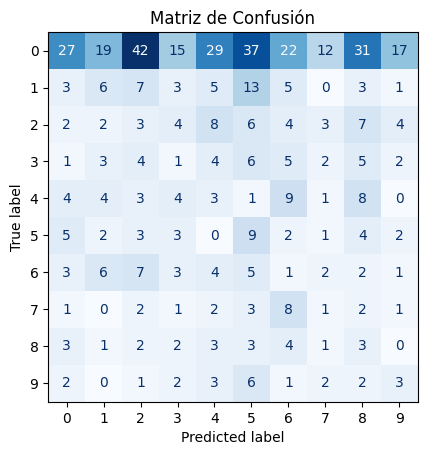

In [742]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False)
plt.title("Matriz de Confusión")
plt.show()
